# The Sorting Trials: Model Evaluation & Comparison

Welcome to the Sorting Trials! Before deploying your Sorting Hat on the ESP32, you must prove your model is worthy. In this notebook, you will rigorously evaluate your decision tree, explore which questions truly matter, compare alternative classifiers, and justify your final deployment choice with evidence.

**Your tasks:**
- Run each cell in order
- Cells marked `# YOUR CODE HERE` require you to write code
- Answer each **Checkpoint** question in the markdown cell provided
- By the end, you will export a trained model as `sorting_hat_model.h` for ESP32 deployment

**Note:** If you change your dataset, use **Kernel > Restart & Run All** to re-run the entire notebook from scratch. This prevents stale variables from causing confusing results.

---
## Section 1: Load & Explore Your Data

First, let's load your dataset and understand its structure. If you haven't collected your own data yet, you can use `sample_dataset.csv` to test the pipeline.

**Note:** The sample dataset is intentionally clean for pipeline testing. Your collected data will likely produce lower accuracy -- that is expected and normal.

**Note:** `random_state=42` is used throughout this notebook to ensure reproducible results. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from micromlgen import port

sns.set_theme(style="whitegrid")
%matplotlib inline

ModuleNotFoundError: No module named 'micromlgen'

In [2]:
# Load your dataset (change the filename to match yours)
df = pd.read_csv("sample_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
df.head(10)

Dataset shape: (40, 11)

Column types:
Question 1      int64
Question 2      int64
Question 3      int64
Question 4      int64
Question 5      int64
Question 6      int64
Question 7      int64
Question 8      int64
Question 9      int64
Question 10     int64
House          object
dtype: object


,Question 1,Question 2,Question 3,Question 4,Question 5,Question 6,Question 7,Question 8,Question 9,Question 10,House
0,1,3,1,2,1,3,1,2,1,3,Gryffindor
1,1,2,1,1,2,3,1,1,1,2,Gryffindor
2,2,3,1,2,1,4,2,1,1,3,Gryffindor
3,1,3,2,1,1,3,1,2,2,3,Gryffindor
4,1,4,1,2,1,3,2,1,1,4,Gryffindor
5,2,3,1,1,2,4,1,2,1,3,Gryffindor
6,1,2,2,2,1,3,1,1,2,2,Gryffindor
7,1,3,1,1,1,3,2,2,1,3,Gryffindor
8,2,4,1,2,2,4,1,1,1,4,Gryffindor
9,1,3,2,1,1,3,1,2,1,2,Gryffindor


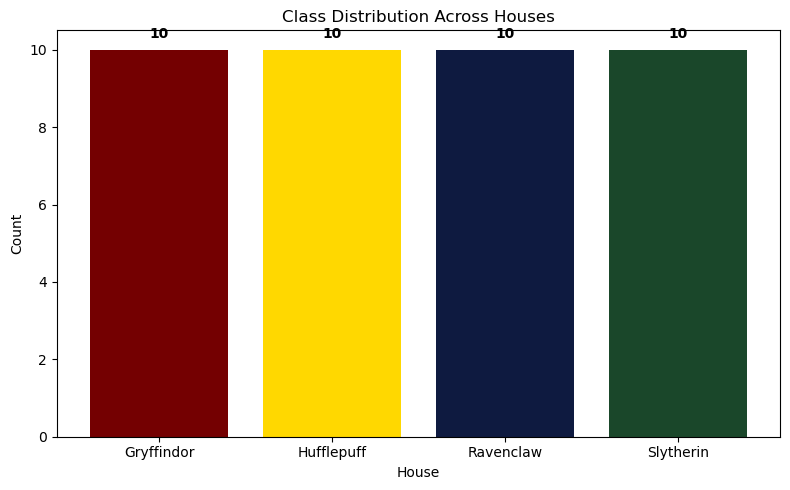

In [3]:
# Plot class distribution
house_counts = df["House"].value_counts()

house_colors = {
    "Gryffindor": "#740001",
    "Hufflepuff": "#FFD800",
    "Ravenclaw": "#0E1A40",
    "Slytherin": "#1A472A"
}
colors = [house_colors.get(h, "#999999") for h in house_counts.index]

plt.figure(figsize=(8, 5))
plt.bar(house_counts.index, house_counts.values, color=colors)
plt.xlabel("House")
plt.ylabel("Count")
plt.title("Class Distribution Across Houses")
for i, (house, count) in enumerate(zip(house_counts.index, house_counts.values)):
    plt.text(i, count + 0.3, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# Prepare features and labels
X = df.drop(columns=["House"])
y = df["House"].astype("category")

# Store the label mapping for later (needed for Arduino switch-case)
label_mapping = dict(enumerate(y.cat.categories))
print("Label mapping (code -> house name):")
for code, name in label_mapping.items():
    print(f"  {code} -> {name}")

y_encoded = y.cat.codes

Label mapping (code -> house name):
  0 -> Gryffindor
  1 -> Hufflepuff
  2 -> Ravenclaw
  3 -> Slytherin


### Checkpoint 1

**Is your dataset balanced? If not, which houses are underrepresented?**

*Your answer here:*

**What are potential consequences of unbalanced dataset?**

*Your answer here:*

---
## Section 2: Baseline Model & Cross-Validation

A single train/test split can give misleading results — the accuracy depends heavily on which samples end up in each set. Cross-validation gives a more reliable estimate by training and testing on multiple splits.

In [ ]:
# Demonstrate the problem with single splits
from sklearn.model_selection import train_test_split

print("Accuracy with different random seeds (single 80/20 split):")
for seed in [0, 1, 2, 42, 99]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=seed
    )
    baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
    baseline.fit(X_train, y_train)
    acc = baseline.score(X_test, y_test)
    print(f"  random_state={seed:2d}  ->  accuracy = {acc:.2f}")

In [ ]:
# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_model = DecisionTreeClassifier(max_depth=5, random_state=42)

scores = cross_val_score(baseline_model, X, y_encoded, cv=cv, scoring="accuracy")

print(f"5-Fold CV Accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"Individual fold scores: {[f'{s:.3f}' for s in scores]}")

### Checkpoint 2

**Is accuracy appropriate as metric for this task? Why or why not**

*Your answer here:*

**How much does accuracy vary across folds? What does this tell you about relying on a single split?**

*Your answer here:*



---
## Section 3: Hyperparameter Tuning (max_depth)

The `max_depth` parameter controls how complex the decision tree can become. Too shallow and it underfits; too deep and it memorizes the training data (overfitting). Let's find the sweet spot.

In [ ]:
depths = range(1, 16)
cv_means = []
cv_stds = []
train_means = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Cross-validation accuracy
    cv_scores = cross_val_score(dt, X, y_encoded, cv=cv, scoring="accuracy")
    cv_means.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())

    # Training accuracy (fit on all data)
    dt.fit(X, y_encoded)
    train_means.append(dt.score(X, y_encoded))

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
train_means = np.array(train_means)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_means, "o-", label="Training Accuracy", color="#740001")
plt.plot(depths, cv_means, "s-", label="CV Accuracy (mean)", color="#0E1A40")
plt.fill_between(depths, cv_means - cv_stds, cv_means + cv_stds,
                 alpha=0.2, color="#0E1A40", label="CV +/- 1 std")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs. Cross-Validation Accuracy")
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(cv_means)]
print(f"\nBest CV accuracy: {cv_means.max():.3f} at max_depth={best_depth}")

In [ ]:
# YOUR CODE HERE: Choose your optimal depth based on the plot above.
# Consider both accuracy and the onset of overfitting (where training
# accuracy keeps rising but CV accuracy plateaus or drops).
chosen_depth = None  # Replace None with your chosen depth

assert chosen_depth is not None, "Set chosen_depth to an integer!"
print(f"Chosen max_depth: {chosen_depth}")

### Checkpoint 3

**At what depth does overfitting begin? What depth did you choose and why?**

*Your answer here:*



---
## Section 4: Feature Importance & Reduction

Not all questions contribute equally to the sorting decision. Let's find out which ones matter most — and whether we can drop the least important ones without losing accuracy.

In [ ]:
# Train model with chosen depth on all data to extract feature importances
best_dt = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
best_dt.fit(X, y_encoded)

importances = best_dt.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color="#1A472A")
plt.xlabel("Feature Importance")
plt.title("Question Importance Scores")
plt.tight_layout()
plt.show()

print("\nFeature importances (sorted):")
for i in reversed(sorted_idx):
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

In [ ]:
# Identify the 3 least important features
bottom_3 = [feature_names[i] for i in sorted_idx[:3]]
print(f"3 least important features: {bottom_3}")

In [ ]:
# Compare: all 10 features vs. top 7 features
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Full model (10 features)
dt_full = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
scores_full = cross_val_score(dt_full, X, y_encoded, cv=cv, scoring="accuracy")

# Reduced model (7 features)
X_reduced = X.drop(columns=bottom_3)
dt_reduced = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
scores_reduced = cross_val_score(dt_reduced, X_reduced, y_encoded, cv=cv, scoring="accuracy")

print(f"All 10 features - CV Accuracy: {scores_full.mean():.3f} +/- {scores_full.std():.3f}")
print(f"Top 7 features  - CV Accuracy: {scores_reduced.mean():.3f} +/- {scores_reduced.std():.3f}")
print(f"Accuracy difference: {scores_full.mean() - scores_reduced.mean():+.3f}")

In [ ]:
# Compare generated C++ code size: 10 features vs. 7 features
dt_full_export = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
dt_full_export.fit(X, y_encoded)
code_full = port(dt_full_export)
size_full = len(code_full.encode("utf-8"))

dt_reduced_export = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
dt_reduced_export.fit(X_reduced, y_encoded)
code_reduced = port(dt_reduced_export)
size_reduced = len(code_reduced.encode("utf-8"))

print(f"C++ code size (10 features): {size_full:,} bytes")
print(f"C++ code size (7 features):  {size_reduced:,} bytes")
print(f"Size difference: {size_full - size_reduced:,} bytes ({(size_full - size_reduced) / size_full * 100:.1f}% reduction)")

### Checkpoint 4

**Which questions contribute least? Can you reduce to 7 questions without significant accuracy loss? Report both accuracy numbers.**

*Your answer here:*



---
## Section 5: Model Comparison

Decision trees are not the only option. Let's compare four classifiers and see which one is best suited for deployment on the ESP32.

**Important:** Not all scikit-learn classifiers can be converted to C++ by `micromlgen`. Part of this exercise is discovering which ones can be deployed on the ESP32 and which ones cannot. The compatibility check below will reveal this.

In [ ]:
# Define models to compare
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=chosen_depth, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=10, max_depth=chosen_depth, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (linear)": SVC(kernel="linear", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=cv, scoring="accuracy")
    results[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"{name:20s}  CV Accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")

In [ ]:
# Confusion matrices for each model
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = cross_val_predict(model, X, y_encoded, cv=cv)
    ConfusionMatrixDisplay.from_predictions(
        y_encoded, y_pred,
        display_labels=[label_mapping[i] for i in sorted(label_mapping.keys())],
        ax=axes[idx],
        cmap="Blues"
    )
    axes[idx].set_title(name)

plt.suptitle("Confusion Matrices (5-Fold CV Predictions)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Classification reports
target_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y_encoded, cv=cv)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_encoded, y_pred, target_names=target_names))

In [ ]:
# Check micromlgen compatibility
print("micromlgen compatibility check:")
print("="*50)

convertible = {}
for name, model in models.items():
    model.fit(X, y_encoded)  # Fit on all data for conversion test
    try:
        c_code = port(model)
        convertible[name] = True
        print(f"  {name:20s}  -> Convertible ({len(c_code):,} chars)")
    except Exception as e:
        convertible[name] = False
        print(f"  {name:20s}  -> NOT convertible ({type(e).__name__})")

In [ ]:
# Summary comparison table
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "CV Accuracy (mean)": [f"{r['mean']:.3f}" for r in results.values()],
    "CV Accuracy (std)": [f"{r['std']:.3f}" for r in results.values()],
    "ESP32 Compatible": ["Yes" if convertible.get(name, False) else "No" for name in results.keys()],
})

print("\nModel Comparison Summary")
print("="*60)
print(comparison_df.to_string(index=False))

### Checkpoint 5

**Which model would you deploy on ESP32? Justify considering accuracy, convertibility, and interpretability.**

*Your answer here:*



---
## Section 6: Edge Deployment Analysis & Export

The ESP32 has limited resources. Let's measure how much space each convertible model takes and make a final deployment decision.

In [ ]:
# Analyze convertible models
deployment_stats = []

for name, model in models.items():
    if not convertible.get(name, False):
        continue

    model.fit(X, y_encoded)
    c_code = port(model)
    file_size = len(c_code.encode("utf-8"))

    stats = {
        "Model": name,
        "CV Accuracy": results[name]["mean"],
        "File Size (bytes)": file_size,
    }

    # Tree-specific stats
    if hasattr(model, "get_depth"):
        stats["Tree Depth"] = model.get_depth()
        stats["Leaf Count"] = model.get_n_leaves()
    elif hasattr(model, "estimators_"):
        avg_depth = np.mean([t.get_depth() for t in model.estimators_])
        total_leaves = sum(t.get_n_leaves() for t in model.estimators_)
        stats["Avg Tree Depth"] = f"{avg_depth:.1f}"
        stats["Total Leaves"] = total_leaves

    deployment_stats.append(stats)
    print(f"{name}:")
    for k, v in stats.items():
        if k != "Model":
            print(f"  {k}: {v}")
    print()

In [ ]:
# Plot: File size vs. Accuracy
if len(deployment_stats) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    for stat in deployment_stats:
        ax.scatter(stat["File Size (bytes)"], stat["CV Accuracy"],
                   s=150, zorder=5)
        ax.annotate(stat["Model"],
                    (stat["File Size (bytes)"], stat["CV Accuracy"]),
                    textcoords="offset points", xytext=(10, 5),
                    fontsize=11)

    ax.set_xlabel("Generated C++ File Size (bytes)")
    ax.set_ylabel("5-Fold CV Accuracy")
    ax.set_title("Model Size vs. Accuracy (ESP32-Compatible Models)")
    ax.axhline(y=0.25, color="gray", linestyle="--", alpha=0.5, label="Random baseline (25%)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Only one convertible model found — no comparison plot needed.")

In [ ]:
# YOUR CODE HERE: Choose your final model for deployment.
# Set final_model to one of the model objects from the 'models' dictionary.
# Example: final_model = models["Decision Tree"]

final_model = None  # Replace None with your chosen model

assert final_model is not None, "Set final_model to a model from the models dictionary!"

In [ ]:
# Export final model to C++ header file
final_model.fit(X, y_encoded)
c_code = port(final_model)

model_filename = "sorting_hat_model.h"
with open(model_filename, "w") as f:
    f.write(c_code)

file_size = len(c_code.encode("utf-8"))
print(f"Model exported to: {model_filename}")
print(f"File size: {file_size:,} bytes")
print(f"\nReminder: Copy '{model_filename}' into the sorting_hat_ESP32/ directory.")
print(f"\nLabel mapping for Arduino switch-case:")
for code, name in label_mapping.items():
    print(f"  case {code}: // {name}")

### Checkpoint 6

**Report your final model's accuracy, file size, and tree depth. Why is this the right choice for ESP32?**

*Your answer here:*

